# notebook to demonstrate effects of balancing dataset

# setup

In [1]:
import network
import torch
import torch.nn as nn
import torch.nn.functional as F

# Unlike object, with SimpleNamespace you can add and remove attributes.
from types import SimpleNamespace 
import numpy as np
import random

# set the network size, to feed into the 1-layer network class

In [13]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # chooses the device for computation

m = 50 # input dimension
n = 100 # measurement dimension

# Set seed
seed = 1
network.set_random_mode(True, seed)

init_parameters = SimpleNamespace()
init_parameters.m = m 
init_parameters.n = n 
init_parameters.seed = seed

# the measurement matrix: randomly initialized
init_parameters.W = torch.randn(n,m).to(device)

# /torch.sqrt(torch.tensor(n)) 

store_image = True

[Random Mode] Deterministic with seed 1


## save the parameters (input-to-measurement weight matrix W)

In [14]:
import pickle
import os

weight_folder = f'weights/m_{m}_n_{n}_s_{seed}'
os.makedirs(weight_folder, exist_ok=True)

param_path = f'{weight_folder}/init_params.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(init_parameters, f)

# create the network

In [15]:
enose_network = network.enose(init_parameters)

#prints network parameters
print("input dimension: " + str(enose_network.m))
print("measurement dimension: " + str(enose_network.n))
print("input-to-measurement matrix: " + str(enose_network.W))

# print network architecture
for name, param in enose_network.named_parameters():
    print(f"{name}: {param.shape}")

input dimension: 50
measurement dimension: 100
input-to-measurement matrix: tensor([[-1.5256, -0.7502, -0.6540,  ..., -0.6298, -0.9274,  0.5451],
        [ 0.0663, -0.4370,  0.7626,  ...,  1.1899,  0.8165, -0.9135],
        [ 1.3851, -0.8138, -0.9276,  ...,  0.6419,  0.4730, -0.4286],
        ...,
        [-1.1080, -1.3766, -0.6012,  ..., -1.4471,  0.1287, -0.2051],
        [ 0.6614,  0.6542,  0.0522,  ..., -1.2430,  0.1239,  0.5274],
        [ 1.7035,  0.5626,  0.3812,  ..., -1.3296, -1.2682, -1.5542]],
       device='mps:0')
fc1.weight: torch.Size([1, 100])
fc1.bias: torch.Size([1])


In [16]:
# parameters
num_data=10000
training_frac=0.8
is_balanced=True
threshold=0.1
x_hat = threshold
num_training = int(num_data*training_frac)
bounds = (0,1)
sparsity_index = None

# create dense dataset with bi-directional option*

In [17]:
# creates dense training dataset, only test set
dataset = network.generate_dataset(m, n, device, num_data, training_frac, is_balanced, threshold, bounds, sparsity_index)
train_conc = dataset.train_conc
train_labels = dataset.train_labels
test_conc = dataset.test_conc
test_labels = dataset.test_labels
test_batch_size = 20


# initial accuracy
initial_accuracy = network.evaluate_random_batch(enose_network, dataset, test_batch_size=20, threshold=0.1)
print(initial_accuracy)

0.6000000238418579


# optimize the parameters using cross entropy, save the trained weights

In [18]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(enose_network.parameters(), lr = 0.001)
lr = 0.001
batch_size = 10
steps = 10000
loss_vec = torch.zeros(steps)

test_interval = 50 # to make sure that all the test data are used multiple times
print_interval = 10000 # how often to print the accuracies and loss in terminal
test_batch_size = 20 
test_iteration_count = 100
accuracy_vec = torch.zeros(steps // test_interval)

# train network on sparse dataset
loss_vec, accuracy_vec = network.train_model(
    enose_network,
    criterion,
    optimizer,
    lr,
    train_conc,
    train_labels,
    test_conc,
    test_labels,
    num_data,
    num_training,
    steps,
    batch_size,
    test_interval,
    print_interval,
    test_batch_size,
    test_iteration_count,
    device
)

# save the model weights
torch.save(enose_network.state_dict(), f"{weight_folder}/model_weights.pth")   

[Step 0] Mean Accuracy over 100 Iterations: 0.5405 | Train Loss: 0.8907


## save mean accuracy, to compare with the accuracy after weight pertubation

In [19]:
# print accuracy vector    
accuracy_vec 

num_step = len(accuracy_vec)
mean_accuracy = torch.mean(accuracy_vec[num_step//2:-1])

param_path = f'{weight_folder}/mean_accuracy.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(mean_accuracy, f)
    
print(num_step)
mean_accuracy

200


tensor(0.9551)

# plot the training loss

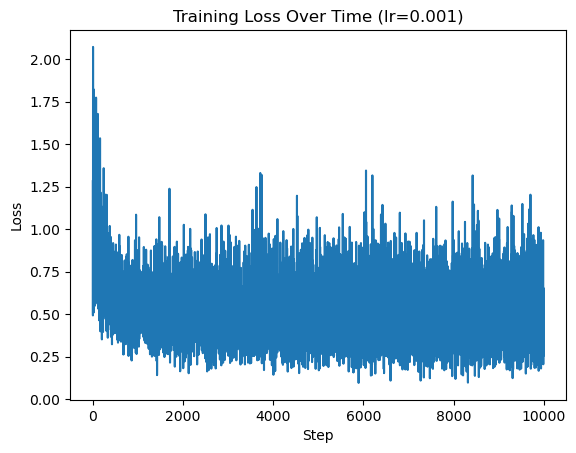

In [18]:
# Plot the loss curve and save (optional)
import matplotlib.pyplot as plt
import os

plt.plot(loss_vec)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time (lr=" + str(lr) + ")")
# Make sure the folder exists
if store_image:
    folder = f'figures/m_{m}_n_{n}_s_{seed}'
    os.makedirs(folder, exist_ok=True)
    plt.savefig(f"{folder}/loss.pdf") 
plt.show()

# plot test accuracy

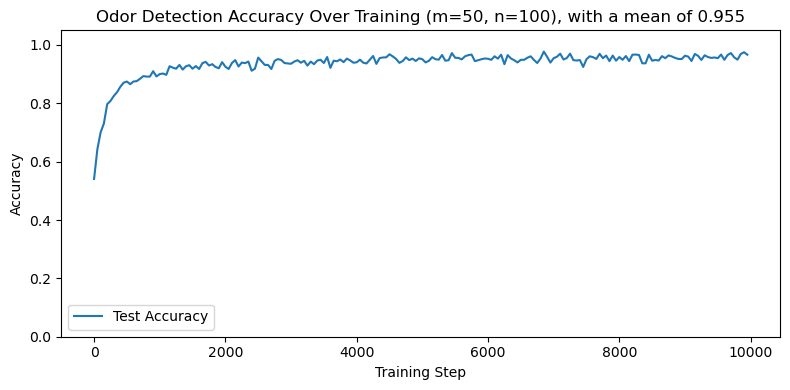

In [20]:
# Plot the test accuracy curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(torch.arange(0, steps, 50), accuracy_vec, label='Test Accuracy')
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title(f"Odor Detection Accuracy Over Training (m={m}, n={n}), with a mean of {mean_accuracy:.3f}")
plt.ylim(0, 1.05)
# plt.grid(True)
plt.legend()
plt.tight_layout()
if store_image:
    folder = './eric_balanced_data_figures'
    plt.savefig(f"{folder}/mean_test_accuracy_vs_step_m={m}_n={n}.pdf")

plt.show()

# plot the weight matrices

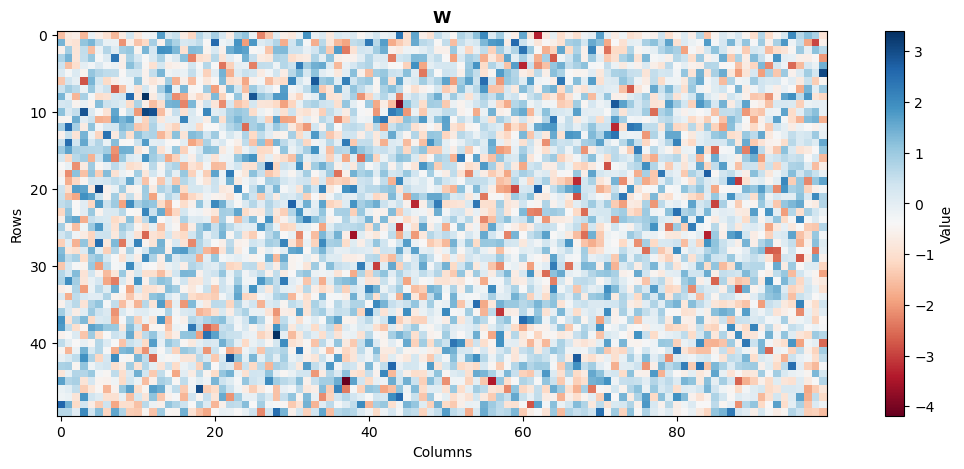

In [20]:
import torch
import matplotlib.pyplot as plt
W = enose_network.W.cpu().numpy()
# Plot using imshow
plt.figure(figsize=(15, 5))
plt.imshow(W, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W.pdf", bbox_inches='tight')
plt.show()

## plot the matrices

In [21]:
enose_network.fc1.bias

Parameter containing:
tensor([0.0185], device='mps:0', requires_grad=True)

1
-0.00462398


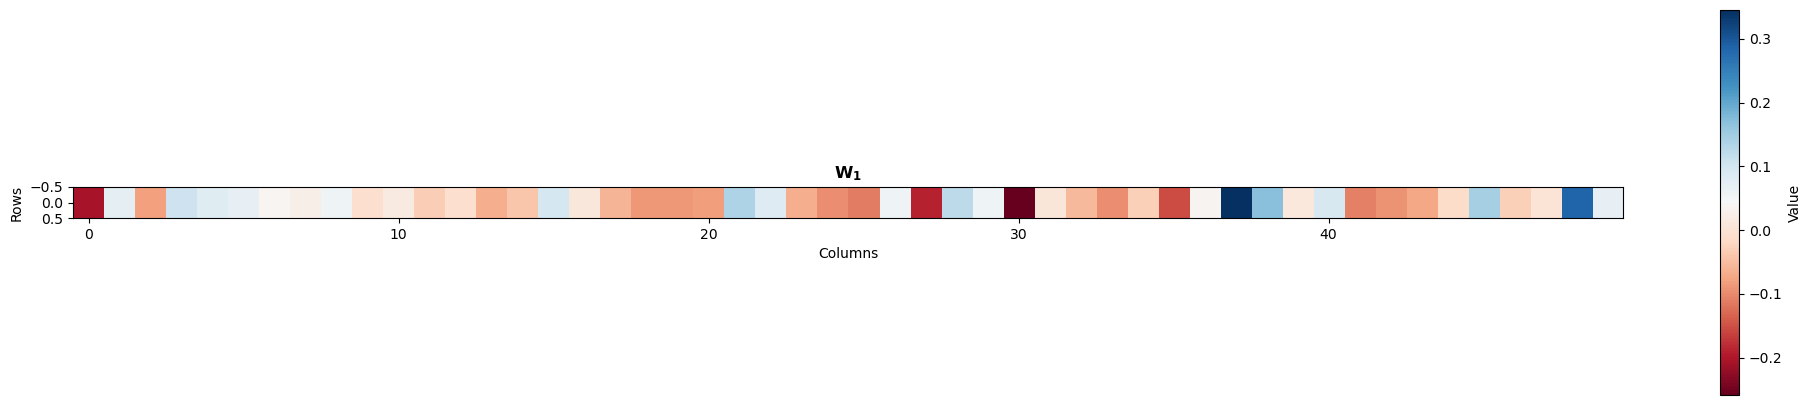

In [22]:
import torch
import matplotlib.pyplot as plt

W1 = enose_network.fc1.weight.detach().cpu().numpy()
b1 = enose_network.fc1.bias.detach().cpu().numpy()
print(b1.size)

W_h = W1 @ W
x1_hat_dagger = -b1[0]/W_h[0,0].item()
print(x1_hat_dagger)

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W1, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W1.pdf", bbox_inches='tight')
plt.show()

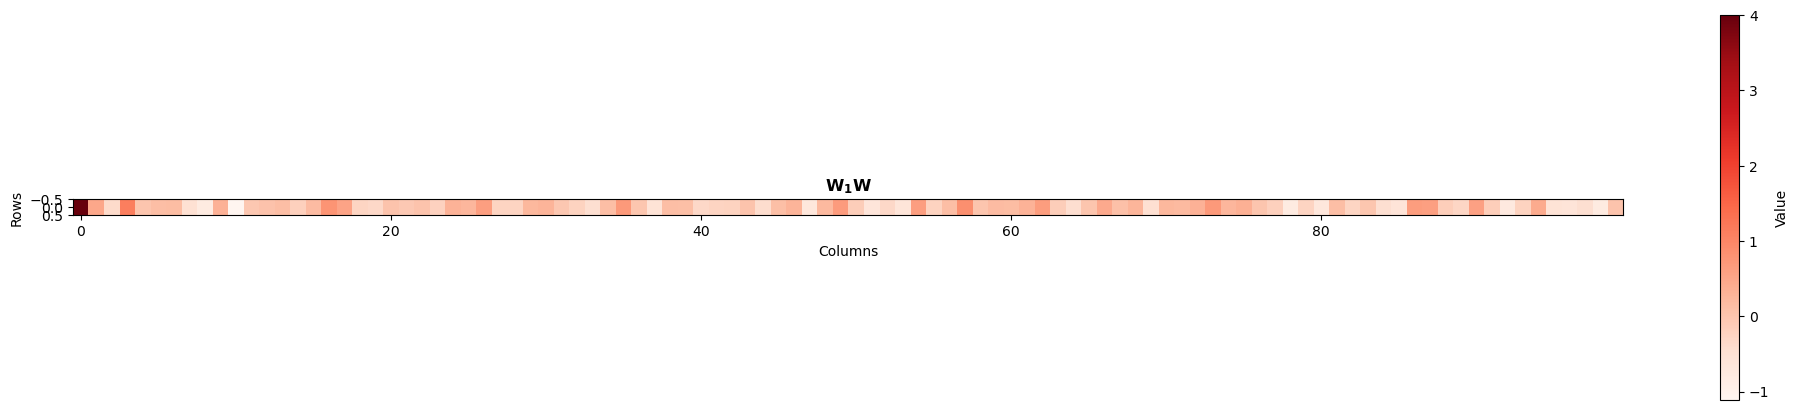

[ 4.00642920e+00  4.79510725e-01 -3.83941889e-01  1.11471188e+00
  4.99753398e-04  1.19092025e-01  1.32174909e-01 -5.01656234e-01
 -7.95502484e-01  3.28424096e-01 -1.10939193e+00 -3.83548588e-02
  3.53648104e-02  1.22960173e-01 -1.90407097e-01  1.69257432e-01
  7.72653937e-01  5.41852236e-01 -2.85655200e-01 -3.48482549e-01
  2.94111371e-02 -5.52205108e-02  2.78680082e-02 -2.25418568e-01
  2.98440605e-01  2.35216245e-01  6.20694995e-01 -2.55895555e-01
 -2.62454897e-01  2.14743122e-01  2.74672657e-01 -4.49839942e-02
 -2.48622835e-01 -4.50079829e-01  1.25133589e-01  7.00225830e-01
 -2.16120910e-02 -5.54548919e-01  1.26145020e-01  1.09265596e-01
 -3.47227901e-01 -2.50589103e-01 -2.39171445e-01  1.88187286e-02
 -4.29426283e-01  1.01787783e-01  2.82485723e-01 -6.72187090e-01
  1.99105904e-01  6.55673623e-01 -1.49960756e-01 -6.39465213e-01
 -3.40554267e-01 -6.23134673e-01  6.26391053e-01 -2.39851892e-01
  1.19765513e-01  8.53782475e-01  2.20088335e-03  1.57952935e-01
  1.40816122e-01  3.06702

In [23]:
import torch
import matplotlib.pyplot as plt

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W_h , cmap='Reds', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1 W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W_h.pdf")
# plt.savefig("figures/W_h.pdf")
plt.show()
plt.close()

# to verify that the first element dominates
print(W_h[0]) 

# plot the simplified 1-D curve, since the first element dominates

In [24]:
x_hat = threshold
print(x_hat)
print(x1_hat_dagger)

0.1
-0.00462398


/var/folders/2w/xwcnb67d2wq2rf_47cyk6vpr0000gn/T/ipykernel_3107/3394132130.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = torch.sigmoid( W_h[0][0]*x + b1 )


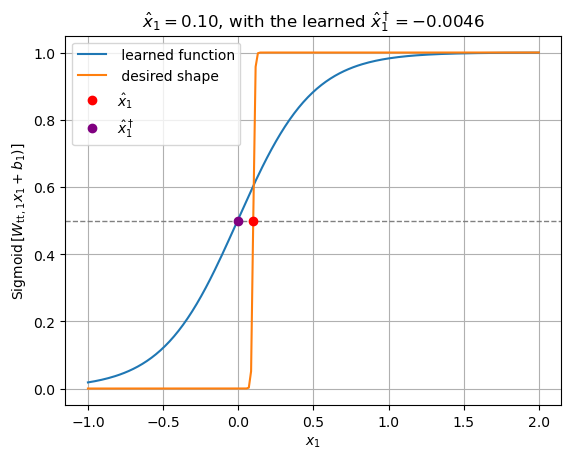

In [25]:
# x = torch.linspace(0, 1, 200)
x = torch.linspace(-1, 2, 200)

y = torch.sigmoid( W_h[0][0]*x + b1 )
y_2 = torch.sigmoid( 200*(x - x_hat) )
plt.plot(x, y, label =' learned function')
plt.plot(x, y_2, label = ' desired shape')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.plot(x_hat, 0.5, 'o', color='red', label=r'$\hat{x}_1$')
plt.plot(x1_hat_dagger, 0.5, 'o', color='purple', label=r'$\hat{x}_1^\dagger$')


plt.title(fr'$\hat{{x}}_1 = {x_hat:.2f} $, with the learned $\hat{{x}}_1^\dagger = {x1_hat_dagger:.4f} $')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\operatorname{Sigmoid}\left[ W_{\operatorname{tt},1} x_1 + b_1 ) \right]$')
plt.legend()
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/pickup_first_dim.pdf", bbox_inches='tight')
plt.show()